# Environment Setup

https://dspy.ai/learn/programming/language_models/

In [ ]:
# Set up observability
# Set up observability
from phoenix.otel import register

# configure the Phoenix tracer
tracer_provider = register(
  project_name="aie-workshop",
  auto_instrument=True # Auto-instrument your app based on installed OI dependencies
)


In [ ]:
import phoenix as px
phoenix_session = px.launch_app()

In [1]:
import dspy
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [ ]:
import os
LM_CONFIG  = {
	"model": os.getenv("DSPY_FAST_MODEL"),
	"api_key": os.getenv("DSPY_API_KEY"),
	"api_base": os.getenv("DSPY_ENDPOINT"),
	"max_tokens": int(os.getenv("DSPY_FAST_MAX_TOKENS",  50_000)),
	"temperature": float(os.getenv("DSPY_FAST_TEMPERATURE",  1.0)),
}

In [ ]:
LM_CONFIG_SMART  = {
	"model": os.getenv("DSPY_SMART_MODEL"),
	"api_key": os.getenv("DSPY_API_KEY"),
	"api_base": os.getenv("DSPY_ENDPOINT"),
}

In [4]:
lm_smart = dspy.LM(**LM_CONFIG_SMART)
lm = dspy.LM(**LM_CONFIG)

## Useful tidbits

- Built-in usage tracking
- Built-in caching
- Global LM variable, with the option to use `with` to swtich for in-line calls

In [5]:
print(lm('hello!'))

# Set the global instance, enable usage tracking
dspy.configure(lm=lm, track_usage=True)

['Hello there! How can I help you today?']


### Simple Sentiment Classifier

In [6]:
SentimentClassifier = dspy.Signature("text: str -> sentiment: int").with_instructions(
    "Classify the sentiment of the text. Lower number is more negative, higher number is more positive."
)

In [7]:
predict = dspy.Predict(SentimentClassifier) 

In [8]:
# output = predict(text="I am feeling pretty happy!")
output = predict(text="This hotel stinks!")
print(output)

Prediction(
    sentiment=1
)


In [9]:
import pprint
pprint.pprint(output.get_lm_usage())

{'openrouter/google/gemini-2.5-flash-lite': {'completion_tokens': 13,
                                             'completion_tokens_details': {'accepted_prediction_tokens': None,
                                                                           'audio_tokens': None,
                                                                           'image_tokens': 0,
                                                                           'reasoning_tokens': 0,
                                                                           'rejected_prediction_tokens': None,
                                                                           'text_tokens': None},
                                             'cost': 2.2275e-05,
                                             'cost_details': {'upstream_inference_completions_cost': 5.2e-06,
                                                              'upstream_inference_cost': None,
                                                    

# Structured information from a PDF

In [10]:
# Attachments/ multimodal / structured output
from attachments.dspy import Attachments

pdf_link = "https://d18rn0p25nwr6d.cloudfront.net/CIK-0001045810/8b76daec-a85f-429a-968c-3c3c9dbae3fc.pdf"

doc = Attachments(pdf_link)

[Attachments] Running primary processor 'pdf_to_llm' for https://d18rn0p25nwr6d.cloudfront.net/CIK-0001045810/8b76daec-a85f-429a-968c-3c3c9dbae3fc.pdf
[Attachments]   Applying step 'load.url_to_response' to https://d18rn0p25nwr6d.cloudfront.net/CIK-0001045810/8b76daec-a85f-429a-968c-3c3c9dbae3fc.pdf
[Attachments]   Applying step 'modify.morph_to_detected_type' to https://d18rn0p25nwr6d.cloudfront.net/CIK-0001045810/8b76daec-a85f-429a-968c-3c3c9dbae3fc.pdf
[Attachments]   Applying step 'load.pdf_to_pdfplumber' to https://d18rn0p25nwr6d.cloudfront.net/CIK-0001045810/8b76daec-a85f-429a-968c-3c3c9dbae3fc.pdf
[Attachments]   Applying step 'modify.pages' to https://d18rn0p25nwr6d.cloudfront.net/CIK-0001045810/8b76daec-a85f-429a-968c-3c3c9dbae3fc.pdf
[Attachments]   Running AdditivePipeline(present.markdown + present.images + present.metadata)
[Attachments]     Applying additive step 'present.markdown' to https://d18rn0p25nwr6d.cloudfront.net/CIK-0001045810/8b76daec-a85f-429a-968c-3c3c9dbae3f


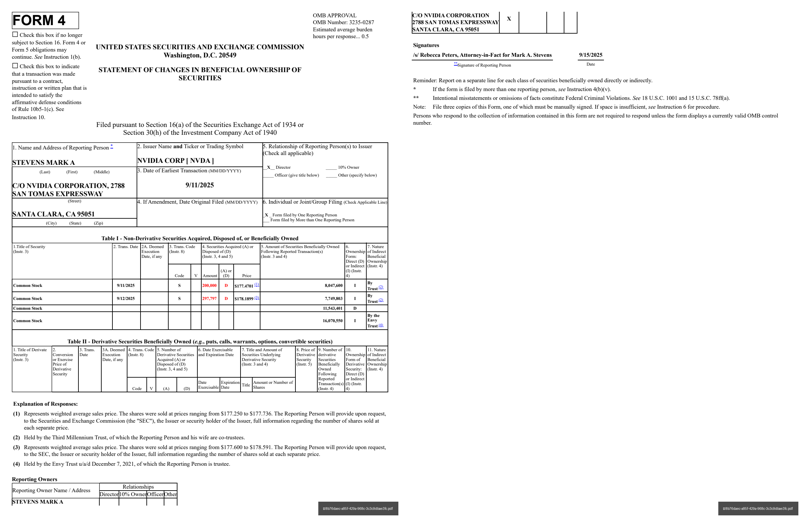

In [11]:
# This is what we're working with
from IPython.display import Image, display

display(Image(url=doc.images[0]))

In [12]:
# from https://maximerivest.github.io/attachments/architecture/#dspy-integration

rag = dspy.ChainOfThought("question, document -> answer")
result = rag(question="How many shares were sold in total?", document=doc)

print(result)

Prediction(
    reasoning='The user is asking for the total number of shares sold. I need to look at Table I - Non-Derivative Securities Acquired, Disposed of, or Beneficially Owned. In this table, the "Trans. Code" column shows \'S\' for sales. I need to sum the amounts in the "Amount (D)" column for all rows where the "Trans. Code" is \'S\'.\n\nThe first sale is for 200,000 shares.\nThe second sale is for 297,797 shares.\nThere are two other entries for "Common Stock" but they do not have a transaction code \'S\' and do not have an amount disposed of. Therefore, they are not sales.\n\nTotal shares sold = 200,000 + 297,797 = 497,797.',
    answer='497,797'
)


In [13]:
print(result.answer)

497,797


### Dynamically generate a schema based on the content itself

In [ ]:
class DocumentAnalyzer(dspy.Signature):
    """Analyze document content and extract insights. """
    document: Attachments = dspy.InputField()
    document_schema: dict = dspy.OutputField(desc="A structured representation of the document content.")

result_schema = dspy.ChainOfThought(DocumentAnalyzer)(document=doc)

In [ ]:
from pprint import pprint
pprint(result_schema.document_schema)

In [ ]:
from pydantic import BaseModel, Field

class Transaction(BaseModel):
    """A transaction in the document."""
    transaction_type: str = Field(description="The type of transaction.")
    shares_sold: int = Field(description="The number of shares sold.")
    price_per_share: float = Field(description="The price per share.")
    total_price: float = Field(description="The total price of the transaction.")

class DocumentSchema(BaseModel):
    """A structured representation of the document content."""
    form_type: str = Field(description="The type of form filed.")
    filing_date: str = Field(description="The date of the filing in the format YYYY-MM-DD.")
    total_shares_sold: int
    transactions: list[Transaction] = Field(description="A list of transactions.")

class DocumentAnalyzerSchema(dspy.Signature):
    """Analyze document content and extract insights. """
    document: Attachments = dspy.InputField()
    document_schema: DocumentSchema = dspy.OutputField(desc="A structured representation of the document content.")

result_schema = dspy.ChainOfThought(DocumentAnalyzerSchema)(document=doc)
pprint(dict(result_schema.document_schema))

# Now use the typed object to get the total shares sold
print("\n\n # Total shares sold: ")
print(result_schema.document_schema.total_shares_sold)

## Adapter Example

In [ ]:
dspy.inspect_history(n=1)

In [ ]:
 #  h/t @tech_optimist


import dspy
from pydantic import BaseModel, Field
from typing import Literal

# Import the BAMLAdapter
from dspy.adapters.baml_adapter import BAMLAdapter

# 1. Define Pydantic models
class PatientAddress(BaseModel):
    street: str
    city: str
    country: Literal["US", "CA"]

class PatientDetails(BaseModel):
    name: str = Field(description="Full name of the patient.")
    age: int
    address: PatientAddress | None

# 2. Define a signature using the Pydantic model as an output field
class ExtractPatientInfo(dspy.Signature):
    '''Extract patient information from the clinical note.'''
    clinical_note: str = dspy.InputField()
    patient_info: PatientDetails = dspy.OutputField()


# Run once with the built-in adapter
with dspy.context(lm=lm_smart):
    # 4. Run your program
    extractor = dspy.Predict(ExtractPatientInfo)
    note = "John Doe, 45 years old, lives at 123 Main St, Anytown. Resident of the US."
    result = extractor(clinical_note=note)
    print(result.patient_info)

# Then run with the BAMLAdapter
with dspy.context(lm=lm_smart, adapter=BAMLAdapter()):
    # 4. Run your program
    extractor = dspy.Predict(ExtractPatientInfo)
    note = "John Doe, 45 years old, lives at 123 Main St, Anytown. Resident of the US."
    result = extractor(clinical_note=note)
    print(result.patient_info)

# Expected output:
# PatientDetails(
#   name='John Doe',
#   age=45,
#   address=PatientAddress(street='123 Main St', city='Anytown', country='US'))


In [ ]:
# Compare the approaches
dspy.inspect_history(n=2)

## Multimodal Example

In [ ]:
img = Attachments("data/parking2.webp")

In [ ]:
from IPython.display import Image, display

display(Image(url=img.images[0]))

In [ ]:
# todays_datetime = "12:30 Tuesday February 4, 2025"
todays_datetime = "12:30 Tuesday February 11, 2025"

sig_parking = dspy.Signature(
    "todays_datetime, parking_sign -> can_park_now: bool, time_to_leave: str"
    )
pred = dspy.ChainOfThought(sig_parking)
print(pred(todays_datetime=todays_datetime, parking_sign=img))

## Module Example

In [ ]:
class ImageAnalyzer(dspy.Module):
    def __init__(self, module_identifier: str):
        super().__init__()

        self.sig_parking = dspy.Signature(
            "todays_datetime, parking_sign -> can_park_now: bool, time_to_leave: str"
            )
        self.predict = dspy.ChainOfThought(self.sig_parking)
        self.module_identifier = module_identifier
        self.count = 0
    
    def forward(self, image):
        print(f"Running {self.module_identifier}; count: {self.count}")
        self.count += 1
        
        todays_datetime = "January 1, 2025, 12:00 PM"
        
        return self.predict(todays_datetime=todays_datetime, parking_sign=image)


analyzer = ImageAnalyzer(module_identifier="AIE123")


In [ ]:

with dspy.context(lm=lm_smart):
    result = analyzer(image=img)
    print(result)

# Tools

In [ ]:
import requests
from typing import List, TypedDict, Literal

class SearchResponse(TypedDict):
    answer: str
    sources: list[str]
    
def pplx_search(
    prompt: str,
    model: Literal["sonar", "sonar-pro", "sonar-reasoning-pro"] = "sonar",
    domain_filter: List[str] = [],
) -> SearchResponse:
    """Search the web for information using Perplexity AI's search models"""
    url = "https://api.perplexity.ai/chat/completions"
    headers = {"Authorization": f"Bearer {os.getenv('PPLX_API_KEY')}"}
    payload = {
        "model": model,
        "messages": [
            {
                "role": "system",
                "content": "You are an exceptionally detailed, capable, and knowledgeable research assistant.",
            },
            {"role": "user", "content": prompt},
        ],
        "search_domain_filter": domain_filter,
    }

    try:
        response = requests.post(url, headers=headers, json=payload, verify=False).json()
        return SearchResponse(
            answer=response["choices"][0]["message"]["content"],
            sources=response.get("citations", []),
        )
    except Exception as e:
        print(f"Error in Perplexity search: {e}")
        return SearchResponse(answer="", sources=[])


# Search functions
def get_url_content(url: str) -> str:
    """Fetch and return the text content from a given URL"""
    try:
        response = requests.get(f"https://r.jina.ai/{url}", verify=False)
        return response.text
    except Exception as e:
        print(f"Error fetching URL content: {e}")
        return



In [ ]:

class BioAgent(dspy.Module):
    def __init__(self):
        super().__init__()
        self.lm = dspy.LM("openrouter/google/gemini-2.5-flash")
        self.answer_generator = dspy.ReAct(
            "user_direction: str, person: str, -> bio: str, applicable_background: bool",
            tools=[pplx_search, get_url_content],
        )

    def forward(self, directions: str, person: str):
        ret = self.answer_generator(user_direction=directions, person=person)
        return ret

    async def aforward(self, directions: str, person: str):
        """Async version of forward method"""
        print("Async: searching for ", person)
        return await self.answer_generator.acall(
            user_direction=directions, person=person
        )


In [ ]:
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

bio_directions = "Identify instances where a person has been at their current company for more than 10 years."

bio_agent = BioAgent()

for person in ["Satya Nadella", "Brian Niccol"]:
    print ("Searching for ", person)
    
    result = bio_agent(directions=bio_directions, person=person)
    
    print(result)


In [ ]:
pprint(result.trajectory)

In [ ]:
import asyncio

async def gather_bio_results():
    people = ["Satya Nadella", "Brian Niccol"]
    bio_agent = BioAgent()
    tasks = [
        bio_agent.aforward(directions=bio_directions, person=person)
        for person in people
    ]
    results = await asyncio.gather(*tasks)
    return dict(zip(people, results))

In [ ]:
await gather_bio_results()

In [ ]:
s_wiki = bio_agent(directions=bio_directions + "Only use wikipedia.org as a source.", person="Satya Nadella")

In [ ]:
pprint(s_wiki.trajectory)

# GEPA Example

In [ ]:
# See https://dspy.ai/tutorials/gepa_facilitysupportanalyzer/

In [ ]:
import requests
import dspy
import json
import random

def init_dataset():
    # Load from the url
    url = "https://raw.githubusercontent.com/meta-llama/llama-prompt-ops/refs/heads/main/use-cases/facility-support-analyzer/dataset.json"
    dataset = json.loads(requests.get(url).text)
    dspy_dataset = [
        dspy.Example({
            "message": d['fields']['input'],
            "answer": d['answer'],
        }).with_inputs("message")
        for d in dataset
    ]
    random.Random(0).shuffle(dspy_dataset)
    train_set = dspy_dataset[:int(len(dspy_dataset) * 0.33)]
    val_set = dspy_dataset[int(len(dspy_dataset) * 0.33):int(len(dspy_dataset) * 0.66)]
    test_set = dspy_dataset[int(len(dspy_dataset) * 0.66):]

    return train_set, val_set, test_set

In [ ]:
train_set, val_set, test_set = init_dataset()

len(train_set), len(val_set), len(test_set)



In [ ]:
print("Input Message:")
print(train_set[0]['message'])

print("\n\nGold Answer:")
for k, v in json.loads(train_set[0]['answer']).items():
    print(f"{k}: {v}")

In [ ]:
from typing import List, Literal


class FacilitySupportAnalyzerUrgency(dspy.Signature):
    """
    Read the provided message and determine the urgency.
    """
    message: str = dspy.InputField()
    urgency: Literal['low', 'medium', 'high'] = dspy.OutputField()

class FacilitySupportAnalyzerSentiment(dspy.Signature):
    """
    Read the provided message and determine the sentiment.
    """
    message: str = dspy.InputField()
    sentiment: Literal['positive', 'neutral', 'negative'] = dspy.OutputField()

class FacilitySupportAnalyzerCategories(dspy.Signature):
    """
    Read the provided message and determine the set of categories applicable to the message.
    """
    message: str = dspy.InputField()
    categories: List[Literal["emergency_repair_services", "routine_maintenance_requests", "quality_and_safety_concerns", "specialized_cleaning_services", "general_inquiries", "sustainability_and_environmental_practices", "training_and_support_requests", "cleaning_services_scheduling", "customer_feedback_and_complaints", "facility_management_issues"]] = dspy.OutputField()

class FacilitySupportAnalyzerMM(dspy.Module):
    def __init__(self):
        self.urgency_module = dspy.ChainOfThought(FacilitySupportAnalyzerUrgency)
        self.sentiment_module = dspy.ChainOfThought(FacilitySupportAnalyzerSentiment)
        self.categories_module = dspy.ChainOfThought(FacilitySupportAnalyzerCategories)
    
    def forward(self, message: str):
        urgency = self.urgency_module(message=message)
        sentiment = self.sentiment_module(message=message)
        categories = self.categories_module(message=message)

        return dspy.Prediction(
            urgency=urgency.urgency,
            sentiment=sentiment.sentiment,
            categories=categories.categories
        )

program = FacilitySupportAnalyzerMM()

In [ ]:
def score_urgency(gold_urgency, pred_urgency):
    """
    Compute score for the urgency module.
    """
    score = 1.0 if gold_urgency == pred_urgency else 0.0
    return score

def score_sentiment(gold_sentiment, pred_sentiment):
    """
    Compute score for the sentiment module.
    """
    score = 1.0 if gold_sentiment == pred_sentiment else 0.0
    return score

def score_categories(gold_categories, pred_categories):
    """
    Compute score for the categories module.
    Uses the same match/mismatch logic as category accuracy in the score.
    """
    correct = 0
    for k, v in gold_categories.items():
        if v and k in pred_categories:
            correct += 1
        elif not v and k not in pred_categories:
            correct += 1
    score = correct / len(gold_categories)
    return score

def metric(example, pred, trace=None, pred_name=None, pred_trace=None):
    """
    Computes a score based on agreement between prediction and gold standard for categories, sentiment, and urgency.
    Returns the score (float).
    """
    # Parse gold standard from example
    gold = json.loads(example['answer'])

    # Compute scores for all modules
    score_urgency_val = score_urgency(gold['urgency'], pred.urgency)
    score_sentiment_val = score_sentiment(gold['sentiment'], pred.sentiment)
    score_categories_val = score_categories(gold['categories'], pred.categories)

    # Overall score: average of the three accuracies
    total = (score_urgency_val + score_sentiment_val + score_categories_val) / 3

    return total

In [ ]:
import dspy
evaluate = dspy.Evaluate(
    devset=test_set,
    metric=metric,
    num_threads=32,
    display_table=True,
    display_progress=True
)

evaluate(program)

In [ ]:
import json
import dspy

def feedback_urgency(gold_urgency, pred_urgency):
    """
    Generate feedback for the urgency module.
    """
    score = 1.0 if gold_urgency == pred_urgency else 0.0
    if gold_urgency == pred_urgency:
        feedback = f"You correctly classified the urgency of the message as `{gold_urgency}`. This message is indeed of `{gold_urgency}` urgency."
    else:
        feedback = f"You incorrectly classified the urgency of the message as `{pred_urgency}`. The correct urgency is `{gold_urgency}`. Think about how you could have reasoned to get the correct urgency label."
    return feedback, score

def feedback_sentiment(gold_sentiment, pred_sentiment):
    """
    Generate feedback for the sentiment module.
    """
    score = 1.0 if gold_sentiment == pred_sentiment else 0.0
    if gold_sentiment == pred_sentiment:
        feedback = f"You correctly classified the sentiment of the message as `{gold_sentiment}`. This message is indeed `{gold_sentiment}`."
    else:
        feedback = f"You incorrectly classified the sentiment of the message as `{pred_sentiment}`. The correct sentiment is `{gold_sentiment}`. Think about how you could have reasoned to get the correct sentiment label."
    return feedback, score

def feedback_categories(gold_categories, pred_categories):
    """
    Generate feedback for the categories module.
    Uses the same match/mismatch logic as category accuracy in the score.
    """
    correctly_included = [k for k, v in gold_categories.items() if v and k in pred_categories]
    incorrectly_included = [k for k, v in gold_categories.items() if not v and k in pred_categories]
    incorrectly_excluded = [k for k, v in gold_categories.items() if v and k not in pred_categories]
    correctly_excluded = [k for k, v in gold_categories.items() if not v and k not in pred_categories]  # For completeness in accuracy check

    # Recompute category accuracy (matches score logic)
    score = (len(correctly_included) + len(correctly_excluded)) / len(gold_categories)

    if score == 1.0:
        fb_text = f"The category classification is perfect. You correctly identified that the message falls under the following categories: `{repr(correctly_included)}`."
    else:
        fb_text = f"The category classification is not perfect. You correctly identified that the message falls under the following categories: `{repr(correctly_included)}`.\n"
        if incorrectly_included:
            fb_text += f"However, you incorrectly identified that the message falls under the following categories: `{repr(incorrectly_included)}`. The message DOES NOT fall under these categories.\n"
        if incorrectly_excluded:
            prefix = "Additionally, " if incorrectly_included else "However, "
            fb_text += f"{prefix}you didn't identify the following categories that the message actually falls under: `{repr(incorrectly_excluded)}`.\n"
        fb_text += "Think about how you could have reasoned to get the correct category labels."
    return fb_text, score

def metric_with_feedback(example, pred, trace=None, pred_name=None, pred_trace=None):
    """
    Computes a score based on agreement between prediction and gold standard for categories, sentiment, and urgency.
    Optionally provides feedback text for a specific predictor module, using the same comparison logic as the score.
    Returns a dspy.Prediction with score (float) and feedback (str).
    """
    # Parse gold standard from example
    gold = json.loads(example['answer'])

    # Compute feedback and scores for all modules
    fb_urgency, score_urgency = feedback_urgency(gold['urgency'], pred.urgency)
    fb_sentiment, score_sentiment = feedback_sentiment(gold['sentiment'], pred.sentiment)
    fb_categories, score_categories = feedback_categories(gold['categories'], pred.categories)

    # Overall score: average of the three accuracies
    total = (score_urgency + score_sentiment + score_categories) / 3

    if pred_name is None:
        return total

    elif pred_name == 'urgency_module.predict':
        feedback = fb_urgency
    elif pred_name == 'sentiment_module.predict':
        feedback = fb_sentiment
    elif pred_name == 'categories_module.predict':
        feedback = fb_categories

    return dspy.Prediction(score=total, feedback=feedback)

In [ ]:
from dspy import GEPA

optimizer = GEPA(
    metric=metric_with_feedback,
    auto="light", # Different options here depending on your compute budget
    num_threads=32, # Watch out for rate limits!
    track_stats=True,
    use_merge=False,
    reflection_lm=lm_smart # This is the model providing feedback - want something smart here
)

In [ ]:
optimized_program = optimizer.compile(
    program,
    trainset=train_set,
    valset=val_set,
)

In [ ]:
for name, pred in optimized_program.named_predictors():
    print("================================")
    print(f"Predictor: {name}")
    print("================================")
    print("Prompt:")
    print(pred.signature.instructions)
    print("*********************************")

In [ ]:
evaluate(optimized_program)